In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

In [2]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")

In [27]:
from tensorflow.keras.models import load_model
basic_cnn = load_model("basic_cnn_phase5.keras")
deep_cnn = load_model("deep_cnn_phase5.keras")
cnn_bn = load_model("cnn_batchnorm_phase5.keras")
cnn_dropout = load_model("cnn_dropout_phase5.keras")
mobilenet_model = load_model("cnn_mobilenet_phase5.keras")
efficientnet_model = load_model("cnn_efficientnet_phase5.keras")
resnet_model = load_model("cnn_resnet_phase5.keras")
densenet_model = load_model("cnn_densenet_phase5.keras")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Library/Frameworks/Python.framework/Versions/3.13/lib/p

In [28]:
class_names = [
    "Actinic Keratosis",
    "Basal Cell Carcinoma",
    "Benign Keratosis",
    "Dermatofibroma",
    "Melanocytic Nevus",
    "Melanoma",
    "Vascular Lesion"
]

In [29]:
models = {
    "Basic CNN": basic_cnn,
    "Deep CNN": deep_cnn,
    "CNN + BN": cnn_bn,
    "CNN + Dropout": cnn_dropout,
    "MobileNetV2": mobilenet_model,
    "EfficientNetB0": efficientnet_model,
    "ResNet50": resnet_model,
    "DenseNet121": densenet_model
}

In [30]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

In [31]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
train_df["label"] = encoder.fit_transform(train_df["disease"])
valid_df["label"] = encoder.transform(valid_df["disease"])
test_df["label"] = encoder.transform(test_df["disease"])

In [32]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
NUM_CLASSES = 7
INPUT_SHAPE = (224,224,3)
BATCH_SIZE = 32

In [33]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

In [34]:
def load_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )
    image = tf.image.resize(
        image,
        (224,224)
    )
    return image
def preprocess(path, label):
    image = load_image(path)
    image = tf.cast(image, tf.float32)
    image = data_augmentation(image)
    return image, label

In [35]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["path"],
        train_df["label"]
    )
)
train_ds = train_ds.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)

In [36]:
valid_ds = tf.data.Dataset.from_tensor_slices(
    (
        valid_df["path"],
        valid_df["label"]
    )
)
valid_ds = valid_ds.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)
valid_ds = valid_ds.batch(BATCH_SIZE)
valid_ds = valid_ds.prefetch(
    tf.data.AUTOTUNE
)

In [37]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["path"],
        test_df["label"]
    )
)
test_ds = test_ds.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(
    tf.data.AUTOTUNE
)

In [38]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)
print(weights)
class_weights = dict(zip(np.unique(train_df["label"]), weights))
print(class_weights)

[ 4.37305053  2.78174603  1.30224782 12.3633157   0.21338772  1.2855309
 10.11544012]
{np.int64(0): np.float64(4.37305053025577), np.int64(1): np.float64(2.7817460317460316), np.int64(2): np.float64(1.3022478172023035), np.int64(3): np.float64(12.36331569664903), np.int64(4): np.float64(0.21338772031292808), np.int64(5): np.float64(1.285530900421786), np.int64(6): np.float64(10.115440115440116)}


In [39]:
y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

In [40]:
def evaluate_model(model, model_name):
    print("="*60)
    print(model_name)
    print("="*60)
    predictions = model.predict(test_ds)
    y_pred = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )
    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )
    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )
    y_true_bin = label_binarize(
        y_true,
        classes=np.arange(7)
    )
    roc = roc_auc_score(
        y_true_bin,
        predictions,
        multi_class="ovr"
    )
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall :", recall)
    print("F1 Score :", f1)
    print("ROC AUC :", roc)
    print()
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc,
        "Prediction": y_pred,
        "Probability": predictions
    }

In [41]:
results = []
results.append(
    evaluate_model(
        basic_cnn,
        "Basic CNN"
    )
)
results.append(
    evaluate_model(
        deep_cnn,
        "Deep CNN"
    )
)
results.append(
    evaluate_model(
        cnn_bn,
        "CNN + BatchNorm"
    )
)
results.append(
    evaluate_model(
        cnn_dropout,
        "CNN + Dropout"
    )
)
results.append(
    evaluate_model(
        mobilenet_model,
        "MobileNetV2"
    )
)
results.append(
    evaluate_model(
        efficientnet_model,
        "EfficientNetB0"
    )
)
results.append(
    evaluate_model(
        resnet_model,
        "ResNet50"
    )
)
results.append(
    evaluate_model(
        densenet_model,
        "DenseNet121"
    )
)

Basic CNN
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step
Accuracy : 0.6300731869594145
Precision: 0.5512475232832469
Recall : 0.6300731869594145
F1 Score : 0.5612697214212654
ROC AUC : 0.7018530728159609

                      precision    recall  f1-score   support

   Actinic Keratosis       0.00      0.00      0.00        49
Basal Cell Carcinoma       0.17      0.70      0.27        77
    Benign Keratosis       0.00      0.00      0.00       165
      Dermatofibroma       0.00      0.00      0.00        17
   Melanocytic Nevus       0.76      0.89      0.82      1006
            Melanoma       0.33      0.01      0.01       167
     Vascular Lesion       0.00      0.00      0.00        22

            accuracy                           0.63      1503
           macro avg       0.18      0.23      0.16      1503
        weighted avg       0.55      0.63      0.56      1503

Deep CNN


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step
Accuracy : 0.669328010645376
Precision: 0.44799998583449646
Recall : 0.669328010645376
F1 Score : 0.5367429084968101
ROC AUC : 0.5013941486208263

                      precision    recall  f1-score   support

   Actinic Keratosis       0.00      0.00      0.00        49
Basal Cell Carcinoma       0.00      0.00      0.00        77
    Benign Keratosis       0.00      0.00      0.00       165
      Dermatofibroma       0.00      0.00      0.00        17
   Melanocytic Nevus       0.67      1.00      0.80      1006
            Melanoma       0.00      0.00      0.00       167
     Vascular Lesion       0.00      0.00      0.00        22

            accuracy                           0.67      1503
           macro avg       0.10      0.14      0.11      1503
        weighted avg       0.45      0.67      0.54      1503

CNN + BatchNorm


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step
Accuracy : 0.669328010645376
Precision: 0.44799998583449646
Recall : 0.669328010645376
F1 Score : 0.5367429084968101
ROC AUC : 0.5

                      precision    recall  f1-score   support

   Actinic Keratosis       0.00      0.00      0.00        49
Basal Cell Carcinoma       0.00      0.00      0.00        77
    Benign Keratosis       0.00      0.00      0.00       165
      Dermatofibroma       0.00      0.00      0.00        17
   Melanocytic Nevus       0.67      1.00      0.80      1006
            Melanoma       0.00      0.00      0.00       167
     Vascular Lesion       0.00      0.00      0.00        22

            accuracy                           0.67      1503
           macro avg       0.10      0.14      0.11      1503
        weighted avg       0.45      0.67      0.54      1503

CNN + Dropout


...

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

47/47 ━━━━━━━━━━━━━━━━━━━━ 36s 737ms/step
Accuracy : 0.3200266134397871
Precision: 0.36079299560236794
Recall : 0.3200266134397871
F1 Score : 0.33338221825147774
ROC AUC : 0.45109291520093897

                      precision    recall  f1-score   support

   Actinic Keratosis       0.00      0.00      0.00        49
Basal Cell Carcinoma       0.00      0.00      0.00        77
    Benign Keratosis       0.05      0.19      0.08       165
      Dermatofibroma       0.00      0.00      0.00        17
   Melanocytic Nevus       0.53      0.45      0.49      1006
            Melanoma       0.00      0.00      0.00       167
     Vascular Lesion       0.00      0.00      0.00        22

            accuracy                           0.32      1503
           macro avg       0.08      0.09      0.08      1503
        weighted avg       0.36      0.32      0.33      1503

EfficientNetB0


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 278ms/step
Accuracy : 0.7298735861610113
Precision: 0.8023255795456016
Recall : 0.7298735861610113
F1 Score : 0.7525649471050581
ROC AUC : 0.9398724841289469

                      precision    recall  f1-score   support

   Actinic Keratosis       0.65      0.45      0.53        49
Basal Cell Carcinoma       0.55      0.70      0.62        77
    Benign Keratosis       0.60      0.58      0.59       165
      Dermatofibroma       0.23      0.94      0.37        17
   Melanocytic Nevus       0.94      0.77      0.85      1006
            Melanoma       0.39      0.69      0.50       167
     Vascular Lesion       0.75      0.68      0.71        22

            accuracy                           0.73      1503
           macro avg       0.59      0.69      0.60      1503
        weighted avg       0.80      0.73      0.75      1503

ResNet50
47/47 ━━━━━━━━━━━━━━━━━━━━ 36s 757ms/step
Accuracy : 0.6360612109115104
Precision: 0.7584682576740238
Recall : 0.636

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [42]:
comparison = pd.DataFrame(results)
comparison = comparison.drop(
    columns=[
        "Prediction",
        "Probability"
    ]
)
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Basic CNN,0.630073,0.551248,0.630073,0.561270,0.701853
1,Deep CNN,0.669328,0.448000,0.669328,0.536743,0.501394
2,CNN + BatchNorm,0.669328,0.448000,0.669328,0.536743,0.500000
3,CNN + Dropout,0.520293,0.574549,0.520293,0.520261,0.673582
4,MobileNetV2,0.320027,0.360793,0.320027,0.333382,0.451093
5,EfficientNetB0,0.729874,0.802326,0.729874,0.752565,0.939872
6,ResNet50,0.636061,0.758468,0.636061,0.671781,0.908033
7,DenseNet121,0.316700,0.357824,0.316700,0.329539,0.449587


In [43]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

In [44]:
comparison = comparison.sort_values(
    "Accuracy",
    ascending=False
)
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
5,EfficientNetB0,0.729874,0.802326,0.729874,0.752565,0.939872
1,Deep CNN,0.669328,0.448000,0.669328,0.536743,0.501394
2,CNN + BatchNorm,0.669328,0.448000,0.669328,0.536743,0.500000
6,ResNet50,0.636061,0.758468,0.636061,0.671781,0.908033
0,Basic CNN,0.630073,0.551248,0.630073,0.561270,0.701853
3,CNN + Dropout,0.520293,0.574549,0.520293,0.520261,0.673582
4,MobileNetV2,0.320027,0.360793,0.320027,0.333382,0.451093
7,DenseNet121,0.316700,0.357824,0.316700,0.329539,0.449587


47/47 ━━━━━━━━━━━━━━━━━━━━ 35s 742ms/step


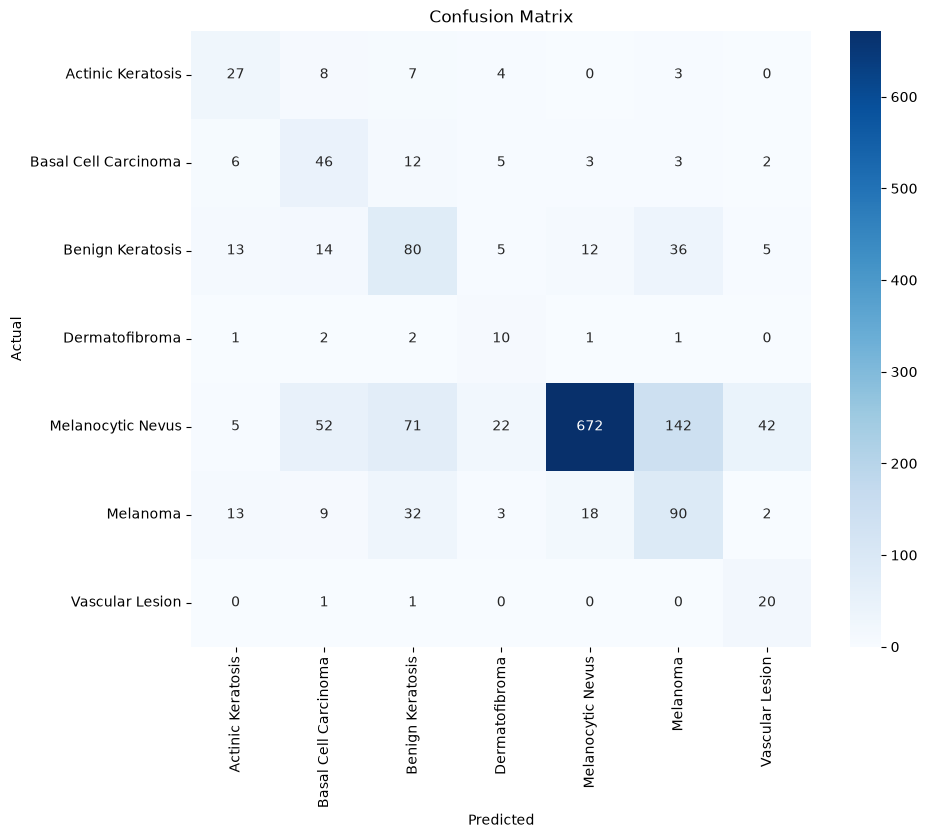

In [49]:
best_model = resnet_model
pred = best_model.predict(test_ds)
pred = np.argmax(pred, axis=1)
cm = confusion_matrix(
    y_true,
    pred
)
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 35s 746ms/step


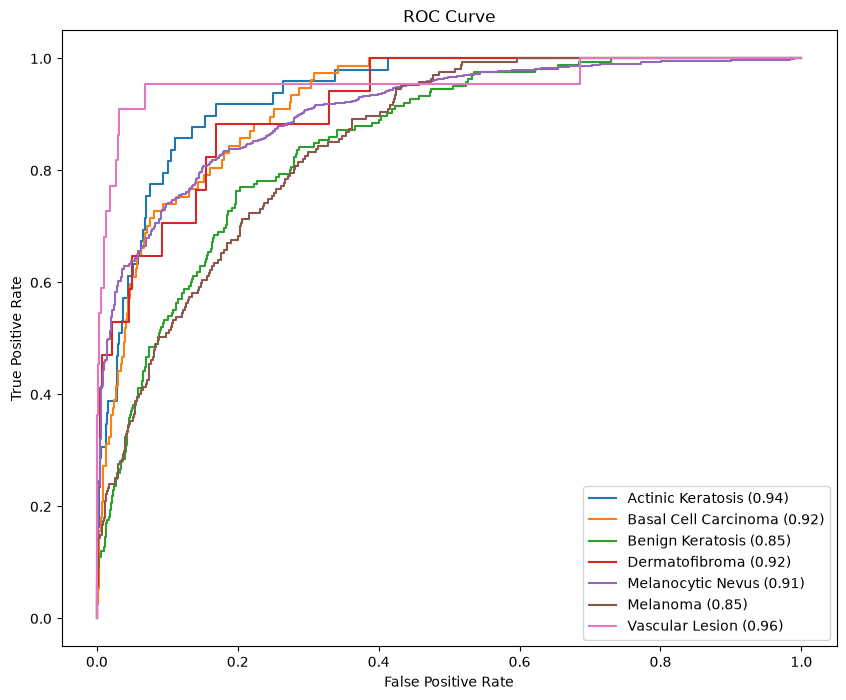

In [50]:
prob = best_model.predict(test_ds)
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(7)
)
plt.figure(figsize=(10,8))
for i in range(7):
    fpr,tpr,_ = roc_curve(
        y_true_bin[:,i],
        prob[:,i]
    )
    roc_auc = auc(fpr,tpr)
    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} ({roc_auc:.2f})"
    )
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

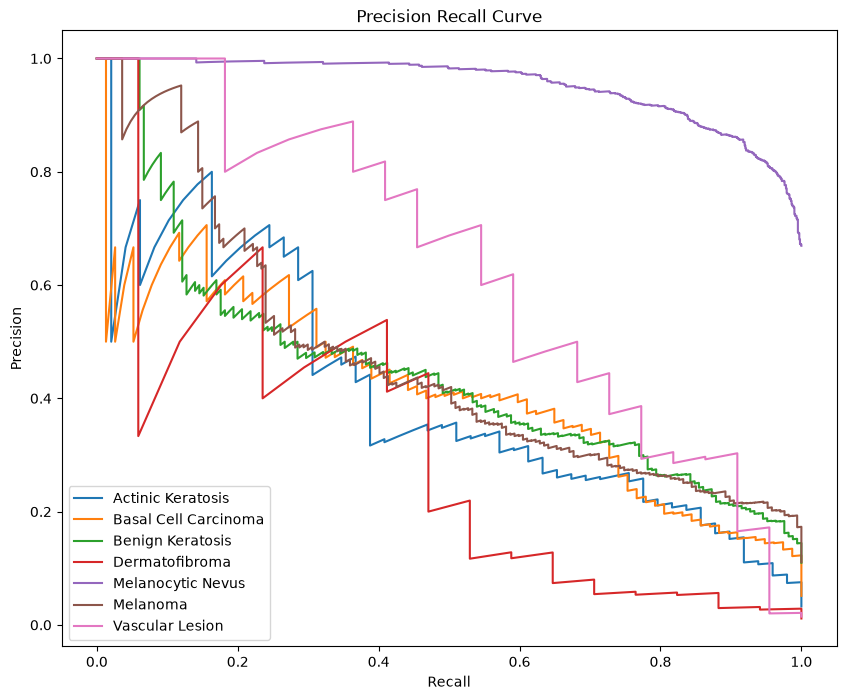

In [51]:
plt.figure(figsize=(10,8))
for i in range(7):
    precision,recall,_ = precision_recall_curve(
        y_true_bin[:,i],
        prob[:,i]
    )
    plt.plot(
        recall,
        precision,
        label=class_names[i]
    )
plt.legend()
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()